# Машинное обучение, DS-поток
## Задание ML.6


**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash; 30 баллов
* Задача 2 &mdash; 105 баллов + бонусные + гуси.

In [ ]:
# Bot check

# HW_ID: ds_ml6
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

### Ссылки на чат с ИИ

Если при решении задач использовался ИИ, укажите здесь ссылки на чаты с ним.

**Задача 1**
1. ...
2. ...

**Задача 2**
1. ...
2. ...



In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import make_scorer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score

from category_encoders import CatBoostEncoder #TargetEncoder без утечки данных

sns.set_palette(palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])
%matplotlib inline

In [8]:
RANDOM_STATE = 42
N_JOBS = 4

---

### Задача 1

Рассмотрим данные из задачи ML.5.3 (`houses_train.csv`) $-$ набор данных про квартиры в городе Сиэтл, штат Вашингтон. Задача — предсказать цену на жилье по имеющимся данным). Задача заключается в сравнении моделей градиентного бустинга из sklearn, для которой категориальные признаки закодированы с помощью
* LabelEncoding,
* MeanEncoding.

Какие признаки будете рассматривать? Какие именно преобразования будете совершать?

In [191]:
data = pd.read_csv('train.csv')
data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,3392,20151013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,18295,20151209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,14569,20151209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
3,14081,20160218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
4,6725,20150627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15621,20922,20160126T000000,429000.0,3,2.00,1490,1126,3.0,0,0,...,8,1490,0,2014,0,98144,47.5699,-122.288,1400,1230
15622,13963,20151014T000000,610685.0,4,2.50,2520,6023,2.0,0,0,...,9,2520,0,2014,0,98056,47.5137,-122.167,2520,6023
15623,9850,20150521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
15624,13975,20160223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200


In [192]:
data.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [193]:
data.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [194]:
data['date'] = pd.to_datetime(data['date'])
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day

Данные имеют следующие столбцы:
* `id` — идентификационный номер жилья
* `date` — дата продажи дома
* `price` — цена
* `bedrooms` — количество спален
* `bathrooms` — количество ванных комнат, где .5 означает комнату с туалетом, но без душа
* `sqft_living` — площадь жилья
* `sqft_lot` — площадь участка
* `floors` — количество этажей
* `waterfront` — видна ли набережная
* `view` — насколько хороший вид
* `condition` — индекс от 1 от 5, отвечающий за состояние квартиры
* `grade` — 1 до 13, 1-3 соответствует плохому уровню строительства и дизайна, 3-7 — средний уровень, 11-13 — высокий.
* `sqft_above` — жилая площадь над уровнем земли
* `sqft_basement` — жилая площадь под уровнем земли
* `yr_built` — год постройки жилья
* `yr_renovated` — год последней реконструкции жилья
* `zipcode` — почтовый индекс
* `lat` — широта
* `long` — долгота
* `sqft_living15` — средняя площадь жилья ближайших 15-и соседей
* `sqft_lot15` — средняя площадь участка ближайших 15-и соседей

In [195]:
print('Количество уникальных значений признака')
for column in data.columns:
    print(f'{column}: {data[column].nunique()}')

Количество уникальных значений признака
id: 15449
date: 369
price: 3288
bedrooms: 11
bathrooms: 30
sqft_living: 883
sqft_lot: 7821
floors: 6
waterfront: 2
view: 5
condition: 5
grade: 12
sqft_above: 806
sqft_basement: 278
yr_built: 116
yr_renovated: 69
zipcode: 70
lat: 4715
long: 714
sqft_living15: 685
sqft_lot15: 7083
year: 2
month: 12
day: 31


Mean encoding буду применять ко всем категориальным: 'waterfront', 'view', 'condition', 'day', 'month', 'year', 'zipcode', 'grade', 'floors'.
Порядковые признаки уже закодированы числами, поэтому применю LabelEncoder к номинальным: 'zipcode'. В деревьях это допустимо, потому что расстояния между признаками учитываются не напрямую

In [196]:
cat_features = ['waterfront', 'view', 'condition', 'day', 'month', 'year', 'zipcode', 'grade', 'floors']

Выполните базовую предобработку данных из задачи ML.5.3

*Совет.* Используйте код из своего решения предыдущего домашнего задания и/или код с семинаров.

In [197]:
X = data.drop(['date', 'price', 'id'], axis=1)
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)

X_train1, X_test1 = X_train.copy(), X_test.copy()
X_train2, X_test2 = X_train.copy(), X_test.copy()

Выполните обработку категориальных признаков

In [198]:
encoder1 = LabelEncoder()
X_train1.loc[:, 'zipcode'] = encoder1.fit_transform(X_train1.loc[:, 'zipcode'])

X_train2[cat_features] = X_train2[cat_features].astype('category')
encoder2 = CatBoostEncoder(random_state=RANDOM_STATE)
X_train2 = encoder2.fit_transform(X_train2, y_train)

In [199]:
X_test1.loc[:, 'zipcode'] = encoder1.transform(X_test1.loc[:, 'zipcode'])

X_test2[cat_features] = X_test2[cat_features].astype('category')
X_test2 = encoder2.transform(X_test2, y_test)

Обучите модели и постройте зависимость значения MAPE от количества деревьев и их максимальной глубины.

In [203]:
N = 200
n_grid = np.arange(1, N + 1)

test_maes1 = []
test_maes2 = []
train_maes1 = []
train_maes2 = []

for n in tqdm(n_grid):
    model1 = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=n)
    model2 = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=n)
    
    model1.fit(X_train1, y_train)
    model2.fit(X_train2, y_train)
    
    test_maes1.append(mean_absolute_error(y_test, model1.predict(X_test1)))
    test_maes2.append(mean_absolute_error(y_test, model2.predict(X_test2)))
    train_maes1.append(mean_absolute_error(y_train, model1.predict(X_train1)))
    train_maes2.append(mean_absolute_error(y_train, model2.predict(X_train2)))

  0%|          | 0/200 [00:00<?, ?it/s]

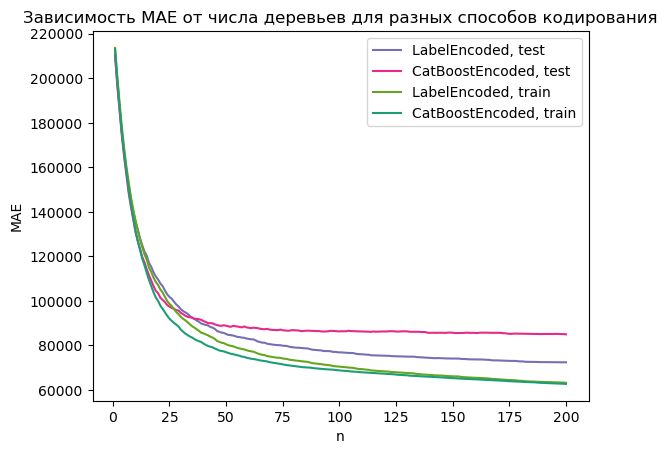

In [204]:
plt.plot(n_grid, test_maes1, label='LabelEncoded, test')
plt.plot(n_grid, test_maes2, label='CatBoostEncoded, test')
plt.plot(n_grid, train_maes1, label='LabelEncoded, train')
plt.plot(n_grid, train_maes2, label='CatBoostEncoded, train')
plt.title('Зависимость MAE от числа деревьев для разных способов кодирования')
plt.xlabel('n')
plt.ylabel('MAE')
plt.legend()
plt.show()

**Выводы:** Видим, что несмотря на более сложное кодирование в данном случае LabelEncoder даёт лучшие результаты при большем количестве деревьев

---

### Задача 2

#### 🤑 Кредитный скоринг
Вы работаете ML-инженером в крупном банке, и вам требуется построить систему **кредитного скоринга** клиентов банка. Кредитный скоринг широко используется в финансовой сфере для оценки кредитоспособности: банки и микрофинансовые организации анализируют данные о клиентах и на основе этого принимают решения о выдаче кредита.  

В данной задаче вам предстоит по набору характеристик клиентов предсказать их **кредитный рейтинг**. Целевая переменная имеет 3 возможных значения: *Хороший*, *Средний* и *Плохой*.  

#### 📊 Оценка результатов
**Основная метрика**: `Accuracy` — доля правильных предсказаний от общего числа примеров.  

**💡 Некоторые советы:**  
- Обратите внимание на категориальные признаки.  
- Подумайте, какие признаки могут быть сильно коррелированы.  
- Не забывайте про общую обработку данных.

#### 📂 Данные
В соревновании вам предоставлены:  
* `train.csv` — обучающие данные с признаками и целевой переменной;  
* `test.csv` — тестовые данные без целевой переменной;  
* `sample_submission.csv` — шаблон для ваших предсказаний.  

**Описание данных:**  

| Признак                 | Тип              | Описание |
| ----------------------- | ---------------- | -------- |
| `client_id`             | целочисленный    | Уникальный идентификатор клиента |
| `month`                 | категориальный   | Месяц сбора информации |
| `age`                   | целочисленный    | Возраст клиента |
| `occupation`            | категориальный   | Вид деятельности |
| `annual_income`         | вещественный     | Годовой доход |
| `monthly_salary`        | вещественный     | Зарплата за текущий месяц |
| `number_bank_accounts`  | целочисленный    | Количество банковских счетов |
| `number_credit_cards`   | целочисленный    | Количество кредитных карт |
| `interest_rate`         | вещественный     | Процентная ставка по кредитной карте |
| `number_loan`           | целочисленный    | Количество кредитов |
| `delay_from_due_date`   | вещественный     | Среднее количество дней задержки выплат |
| `number_delayed_payment`| целочисленный    | Количество задержанных платежей |
| `number_credit_inquiries`| целочисленный   | Количество запросов по кредиту |
| `unpaid_debt`           | вещественный     | Сумма долга |
| `credit_utilization_ratio`| вещественный   | Коэффициент использования кредитных карт |
| `credit_history_age`    | строка    | Размер кредитной истории  |
| `min_amount_payment`    | бинарный         | Флаг: произведена ли минимальная выплата |
| `monthy_amount_invested`| вещественный     | Сумма инвестиций за месяц |
| `client_behaviour`      | категориальный   | Платежное поведение клиента |
| `monthly_balance`       | вещественный     | Баланс по итогу месяца |
| `credit_rating`         | целевая (катег.) | Кредитный рейтинг клиента |

Ссылка: https://www.kaggle.com/competitions/ds-3-2025-ml-6/

Инвайт: https://www.kaggle.com/t/c56563c80c5547b9960a7f71859377a1

**Правила**

* В Kaggle в данное тренировочное соревнование можно отправлять не более 7 решений в день (8-ю система не позволит).
* Решения индивидуальные.
* Качество считается по метрике Accuracy.
* До окончания соревнования доступны значения качества, посчитанные только на случайных 30% тестовых данных. Значения отображаются в Public Leaderboard.
* После окончания соревнования становится доступным Private Leaderboard, в котором значения качества посчитанны на оставшихся 70% объектов.
* Для включения в Private Leaderboard можно выбрать две посылки.
* В Leaderboard должны отображаться ваши **реальные имя и фамилия**. В противном случае решение может быть не зачтено.
* Все файлы, которые вы отправляете в соревнование, видны организаторам соревнования. Файлы должны иметь понятное имя, при отправке файла в систему необходимо написать краткое описание решения. **Это будет проверяться.**
* В решении, отправляемом боту, должно быть отображено, результаты каких моделей вы отправляете в соревнование.
* Не забывайте сделать пояснения к своему решению. **Решение может быть не зачтено, если в нем недостаточно пояснений**, даже если удалось попасть в топ-3.
* Пользоваться можно любыми пройденными в наших курсах моделями.
* Нельзя пользоваться любыми методами и моделями, которые мы не проходили, и которых не было в ранее в иных курсах, которые обязательны для всех.
* Код студентов, занявших первые 3 места, будет запускаться. Также выборочно может запускаться код и остальных студентов.

**Советы**

* Чтобы получить действительно хороший результат подбора гиперпараметров мало, попробуйте ввести новые признаки для улучшения качества решения.
* Некоторые инсайты по тому, какие признаки могут улучшить качество, можно получить если провести разведывательный анализ данных (EDA). Например, может иметь смысл изучить датасет на предмет наличия выбросов, исследовать пространственное и временное распределение отклика.
* Изучите различные методы, предложенные на занятиях.
* Сохраняйте код и результаты каждой модели в отдельных файлах. Добавляйте к ним понятные описания, которые помогут вам при необходимости продолжить использовать решение.

**Сроки сдачи**

* **Дедлайн в Kaggle** совпадает с дедлайном по заданию (15.10 16:00). Дедлайн строгий, Kaggle не позволит сдать даже на секунду позже.
* Также **до дедлайна необходимо сдать в бот** существующий вариант решения, возможно, без пояснений.
* **До конца следующих суток  (16.10 23:59)** необходимо дооформить решение, соответствующее наилучшему варианту по Private Leaderboard и сдать в бот по отдельной кнопке. **Решение может быть не зачтено, если в нем недостаточно пояснений**, даже если удалось попасть в топ-3.
* В случае, если вы до основного дедлайна сдаете оформленное решение, его нужно сдать по двум кнопкам сразу &mdash; соответствующей основной сдаче, и отдельной для оформленного решения.

**Баллы**

* **Выдаются только при соблюдении всех правил** и суммируются.
* по 15 баллов — за каждый преодоленный порог по метрике Accuracy на Private Leaderboard, пороги: 0.675, 0.672, 0.669, 0.666, 0.663, 0.65, 0.6.
* 15 баллов за попадание в топ-3 на Private Leaderboard.
* 15 баллов за попадание в топ-1 на Private Leaderboard (30 баллов суммарно с топ-3)
* Доп. призы за места в топ-3 : **мягкий гусь**
    * за топ-1 на Private Leaderboard
    * за наиболее хорошо оформленное решение
    * за самую оригинальную идею (которая привела к улучшению).

---
### Preprocessing

In [2]:
df_train = pd.read_csv('KaggleTrain.csv')
df_test = pd.read_csv('KaggleTest.csv')

In [209]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   client_id                 64000 non-null  object 
 1   month                     64000 non-null  object 
 2   age                       59135 non-null  float64
 3   occupation                59459 non-null  object 
 4   annual_income             59531 non-null  float64
 5   monthly_salary            54401 non-null  float64
 6   number_bank_accounts      64000 non-null  int64  
 7   number_credit_cards       64000 non-null  int64  
 8   interest_rate             61720 non-null  float64
 9   number_loan               58215 non-null  float64
 10  delay_from_due_date       64000 non-null  int64  
 11  number_delayed_payment    56849 non-null  float64
 12  number_credit_inquiries   61489 non-null  float64
 13  unpaid_debt               63358 non-null  float64
 14  credit

Разобьём train на X и y

In [211]:
df_train.head(3)

,client_id,month,age,occupation,annual_income,monthly_salary,number_bank_accounts,number_credit_cards,interest_rate,number_loan,...,number_delayed_payment,number_credit_inquiries,unpaid_debt,credit_utilization_ratio,credit_history_age,min_amount_payment,monthy_amount_invested,client_behaviour,monthly_balance,credit_rating
0,5e261a2ce0,Февраль,NaN,NaN,34811.50,2977.666667,2,4,6.0,1.0,...,4.0,2.0,605.03,24.464031,26 г. 7 м.,No,104.291825,"Малые траты, малые платежи",463.220627,Обычный
1,5e261a2ce0,Март,28.0,Учитель,34231.28,2991.866667,2,4,6.0,1.0,...,1.0,2.0,605.03,38.550848,26 г. 8 м.,No,40.391238,"Большие траты, большие платежи",478.941214,Хороший
2,5e261a2ce0,Апрель,28.0,Учитель,NaN,2979.906667,2,1385,6.0,1.0,...,NaN,2.0,605.03,33.224951,26 г. 9 м.,No,58.515976,"Большие траты, большие платежи",464.256476,Обычный


Посмотрим количество уникальных, чтобы определиться с наличием скрытых категорильных признаков, какую кодировку использовать

In [212]:
print('Количество уникальных значений признака')
for column in df_train.columns:
    print(f'{column}: {df_train[column].nunique()}')

Количество уникальных значений признака
client_id: 8000
month: 8
age: 47
occupation: 15
annual_income: 59377
monthly_salary: 54291
number_bank_accounts: 691
number_credit_cards: 951
interest_rate: 66
number_loan: 10
delay_from_due_date: 76
number_delayed_payment: 29
number_credit_inquiries: 17
unpaid_debt: 7868
credit_utilization_ratio: 64000
credit_history_age: 404
min_amount_payment: 3
monthy_amount_invested: 58275
client_behaviour: 6
monthly_balance: 63207
credit_rating: 3


Посмотрим, есть ли смысл использовать client_id

In [213]:
print('Количество тех же клиентов в train и test:', len(set(df_train['client_id']) & set(df_test['client_id'])))

Количество тех же клиентов в train и test: 0


Выходит, что клиенты взяты по несколько раз в некоторые месяцы, просто для статистики, так что эти две колонки можон убирать

In [3]:
df_train = df_train.drop(['client_id', 'month'], axis=1)

Распарсим client_behaviour

In [214]:
print(df_train['client_behaviour'].unique())

['Малые траты, малые платежи' 'Большие траты, большие платежи'
 'Малые траты, средние платежи' 'Большие траты, средние платежи'
 'Малые траты, большие платежи' 'Большие траты, малые платежи' nan]


In [4]:
spendings = []
payments = []
for cb in df_train['client_behaviour']:
    if pd.isna(cb):
        spendings.append('nan')
        payments.append('nan')
    else:
        cb = cb.split()
        if cb[0] == 'Малые':
            spendings.append('малые')
        else:
            spendings.append('большие')
        payments.append(cb[2])

df_train['spendings'] = spendings
df_train['payments'] = payments
df_train = df_train.drop(['client_behaviour'], axis=1)

Распарсим credit_history_age

In [5]:
credit_history_age = []
for ch in df_train['credit_history_age']:
    if pd.isna(ch):
        credit_history_age.append(np.nan)
    else:
        y, _, m, _ = ch.split()
        y = int(y)
        m = int(m)
        credit_history_age.append(y * 12 + m)    

df_train = df_train.drop(['credit_history_age'], axis=1)
df_train['credit_history_age'] = credit_history_age

In [6]:
X, y = df_train.drop(['credit_rating'], axis=1), df_train['credit_rating']

In [9]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_test = df_test.copy()

In [10]:
num_cols = ['age', 'annual_income',
       'monthly_salary', 'number_bank_accounts', 'number_credit_cards',
       'interest_rate', 'number_loan', 'delay_from_due_date',
       'number_delayed_payment', 'number_credit_inquiries', 'unpaid_debt',
       'credit_utilization_ratio',
       'monthy_amount_invested', 'monthly_balance', 'credit_history_age']

In [11]:
cat_cols = ['occupation', 'min_amount_payment', 'spendings', 'payments']

In [12]:
def preproc():
    df_train = pd.read_csv('KaggleTrain.csv')
    df_test = pd.read_csv('KaggleTest.csv')
    df_train = df_train.drop(['client_id', 'month'], axis=1)
    spendings = []
    payments = []
    for cb in df_train['client_behaviour']:
        if pd.isna(cb):
            spendings.append('nan')
            payments.append('nan')
        else:
            cb = cb.split()
            if cb[0] == 'Малые':
                spendings.append('малые')
            else:
                spendings.append('большие')
            payments.append(cb[2])
    
    df_train['spendings'] = spendings
    df_train['payments'] = payments
    df_train = df_train.drop(['client_behaviour'], axis=1)
    credit_history_age = []
    for ch in df_train['credit_history_age']:
        if pd.isna(ch):
            credit_history_age.append(np.nan)
        else:
            y, _, m, _ = ch.split()
            y = int(y)
            m = int(m)
            credit_history_age.append(y * 12 + m)    
    
    df_train = df_train.drop(['credit_history_age'], axis=1)
    df_train['credit_history_age'] = credit_history_age
    X, y = df_train.drop(['credit_rating'], axis=1), df_train['credit_rating']
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    
    X_test = df_test.copy() 
    X_test = X_test.drop(['client_id', 'month'], axis=1)
    spendings = []
    payments = []
    for cb in X_test['client_behaviour']:
        if pd.isna(cb):
            spendings.append('nan')
            payments.append('nan')
        else:
            cb = cb.split()
            if cb[0] == 'Малые':
                spendings.append('малые')
            else:
                spendings.append('большие')
            payments.append(cb[2])
    
    X_test['spendings'] = spendings
    X_test['payments'] = payments
    X_test = X_test.drop(['client_behaviour'], axis=1)
    credit_history_age = []
    for ch in X_test['credit_history_age']:
        if pd.isna(ch):
            credit_history_age.append(np.nan)
        else:
            x, _, m, _ = ch.split()
            x = int(x)
            m = int(m)
            credit_history_age.append(x * 12 + m)    
    
    X_test = X_test.drop(['credit_history_age'], axis=1)
    X_test['credit_history_age'] = credit_history_age

    return X_train, X_valid, y_train, y_valid, X_test, X, y

In [13]:
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()

---
### EDA

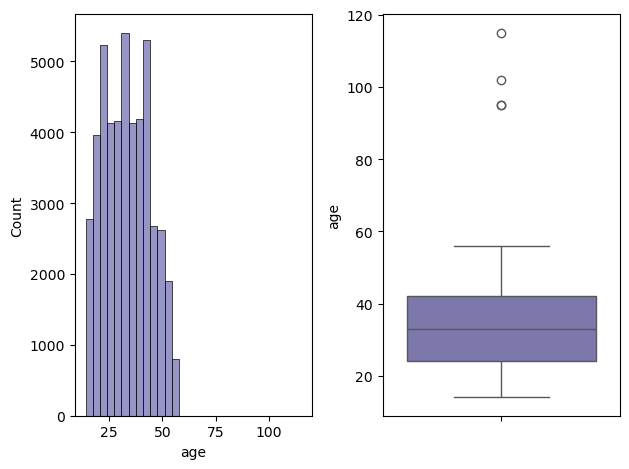

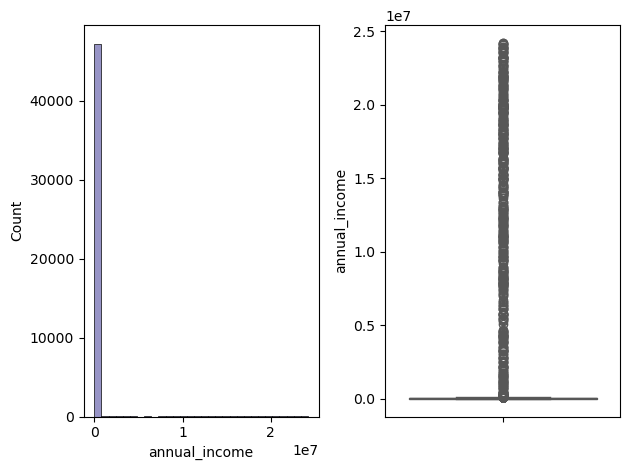

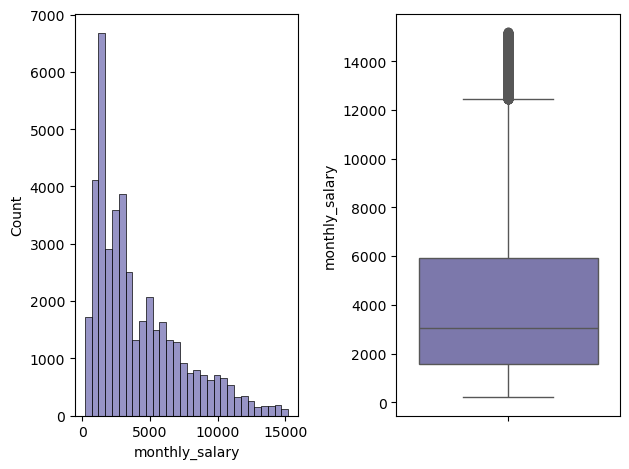

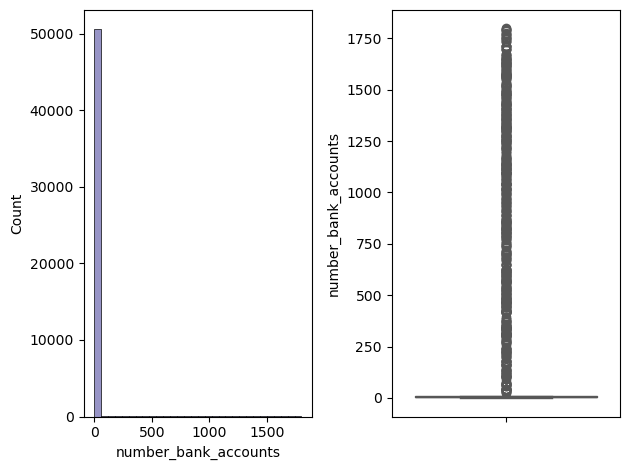

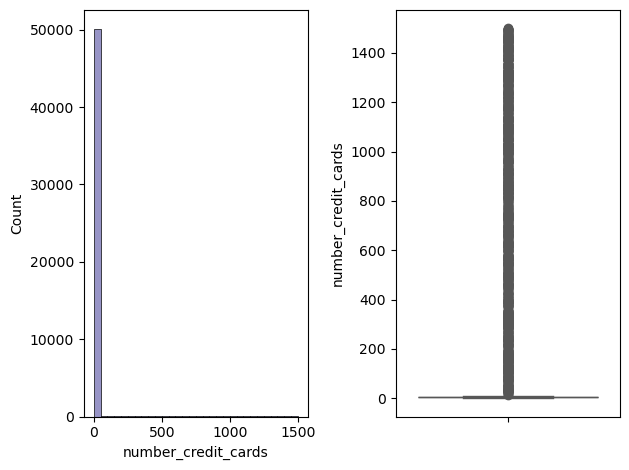

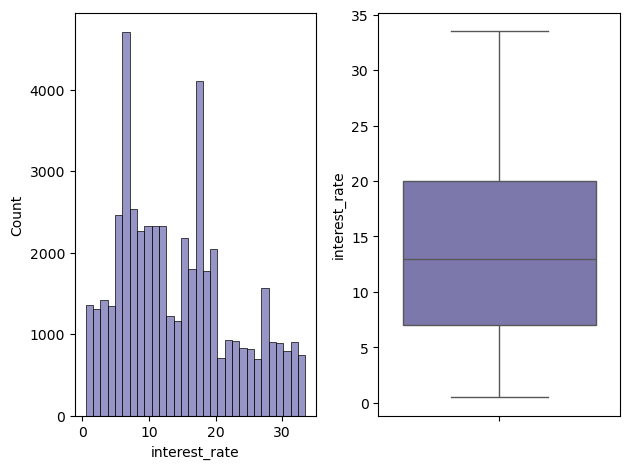

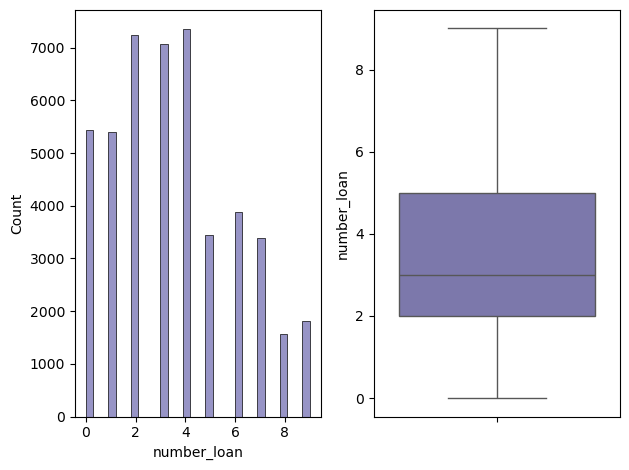

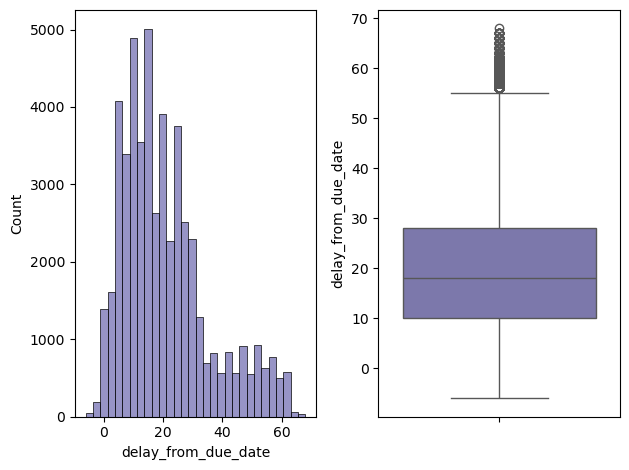

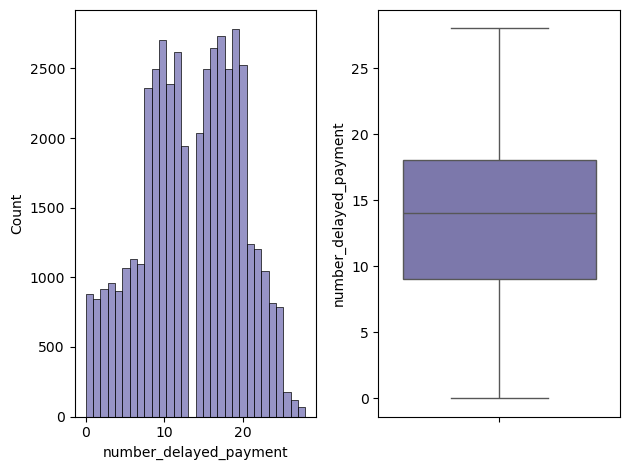

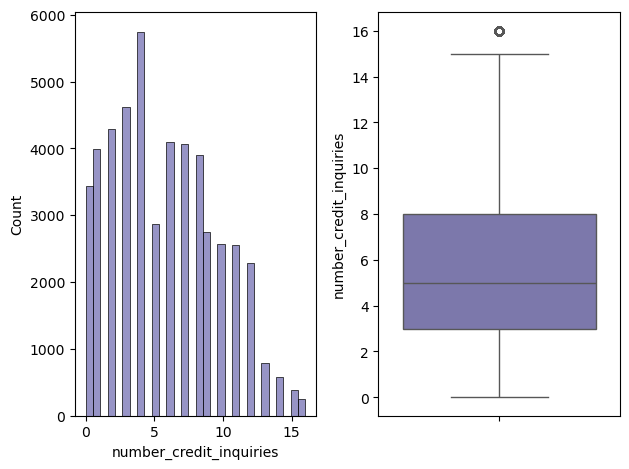

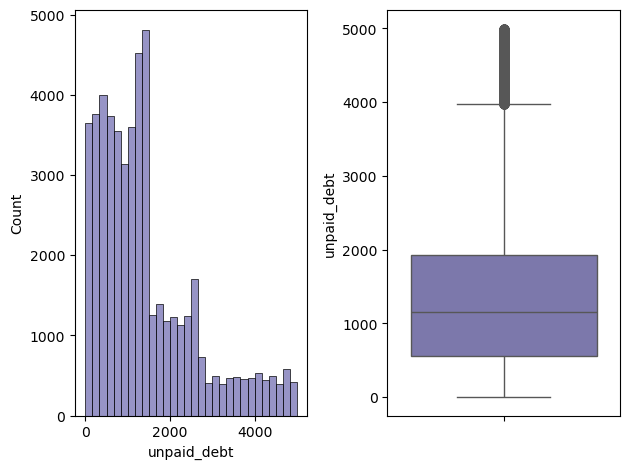

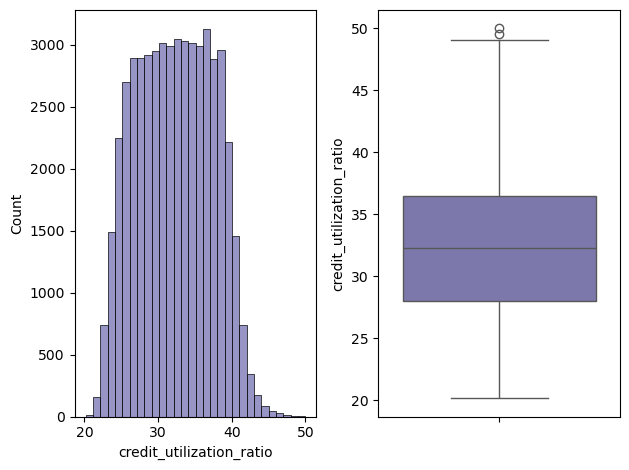

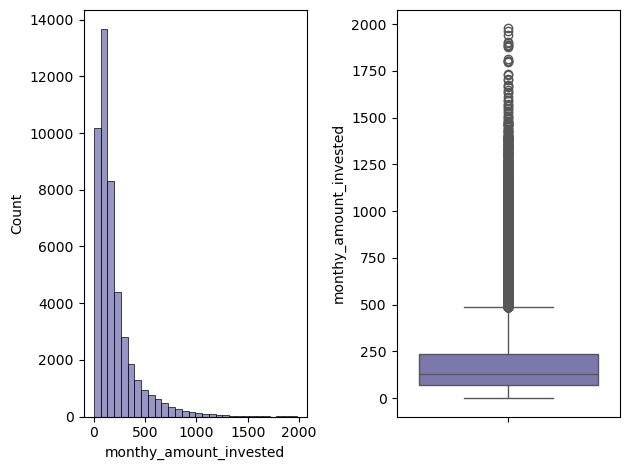

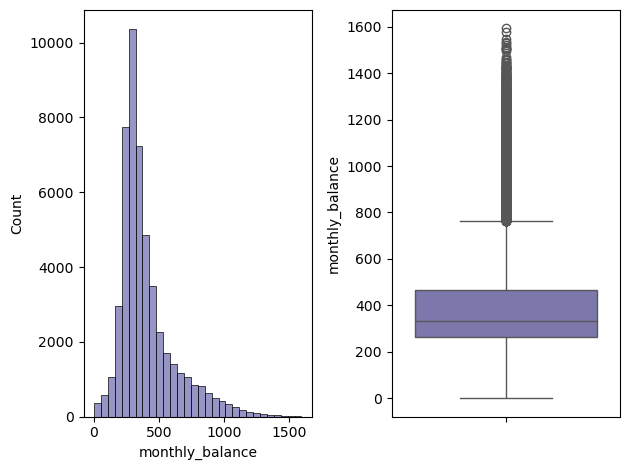

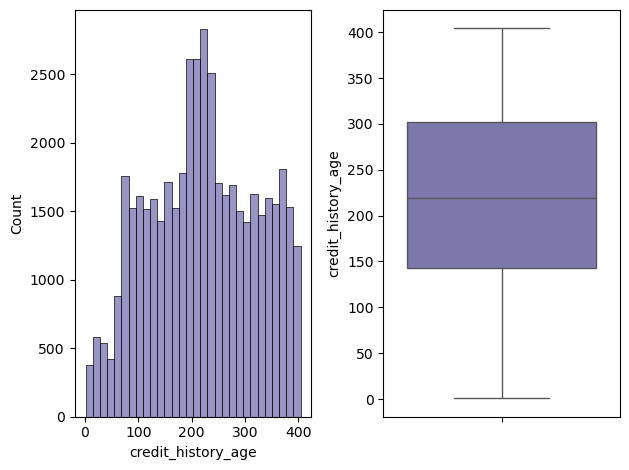

In [522]:
for feature in num_cols:
    fig, ax = plt.subplots(ncols=2)
    sns.histplot(X_train[feature], ax=ax[0], bins=30)
    sns.boxplot(X_train[feature], ax=ax[1])
    plt.tight_layout()
    plt.show()

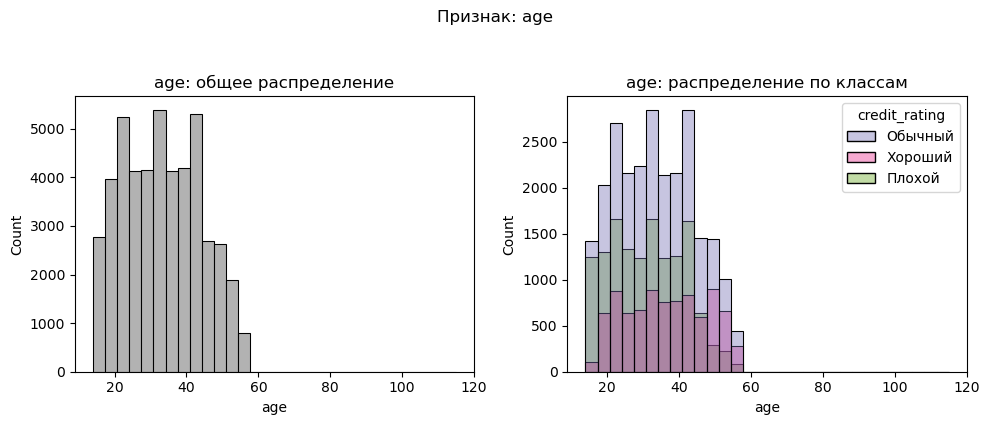

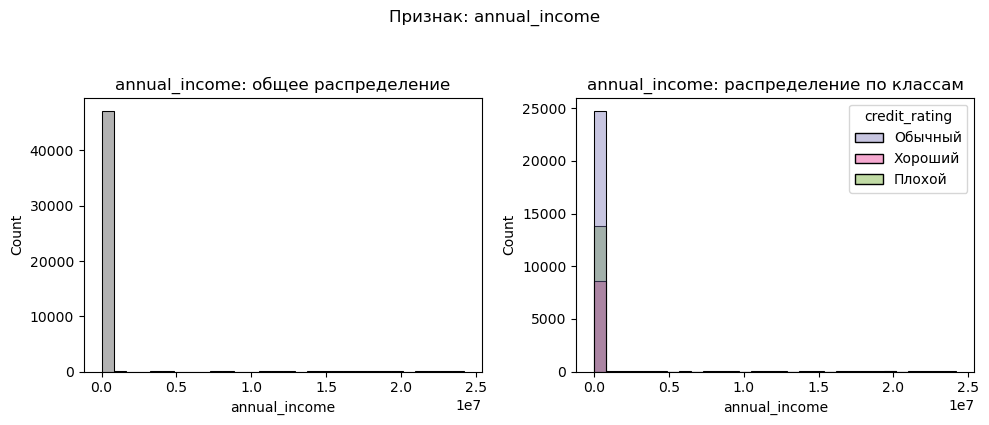

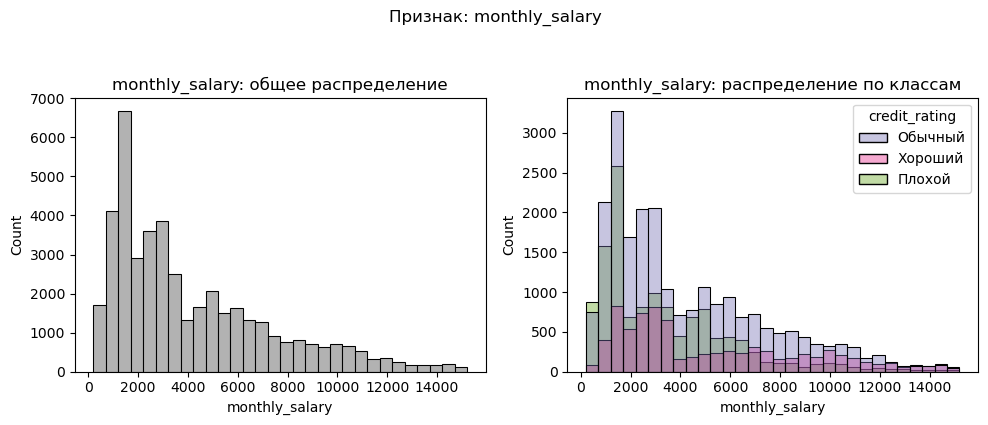

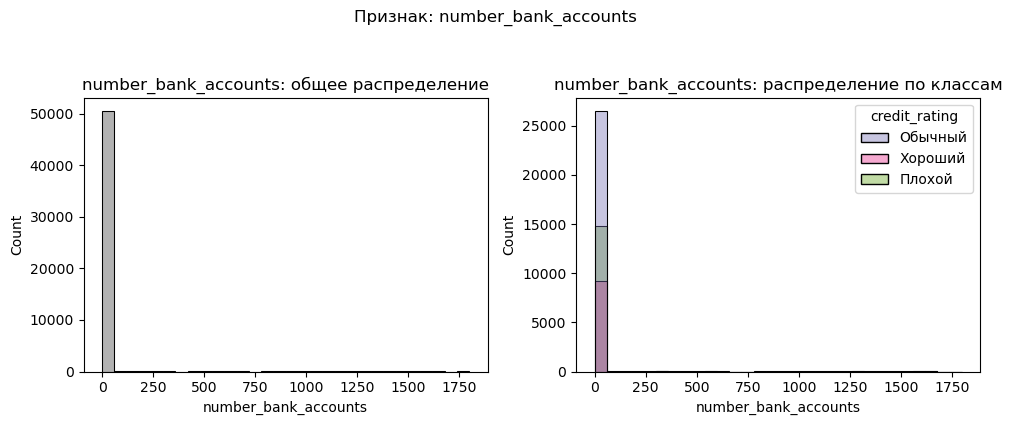

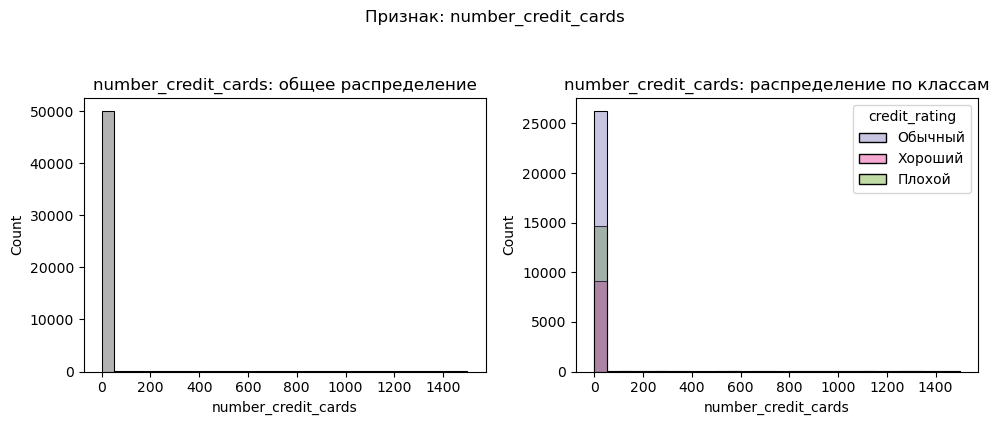

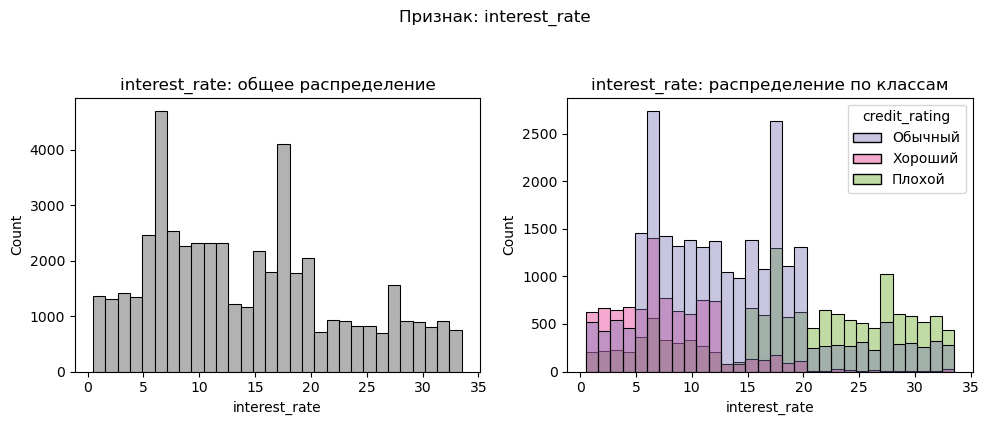

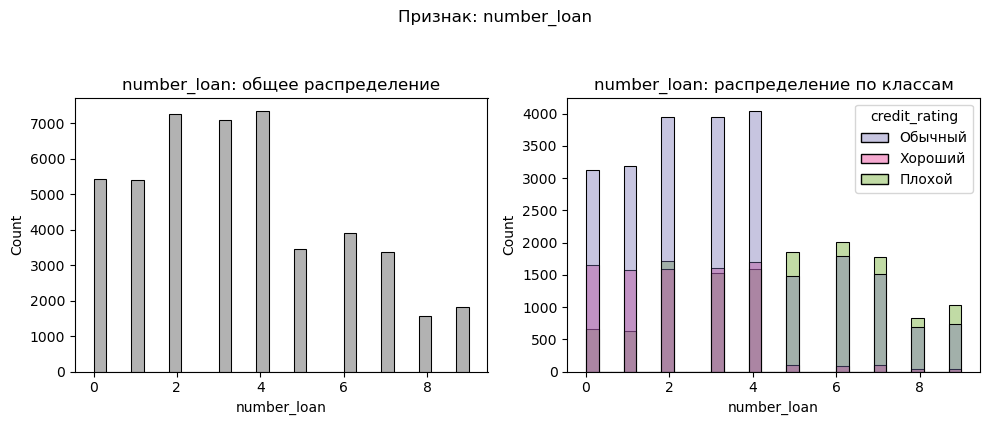

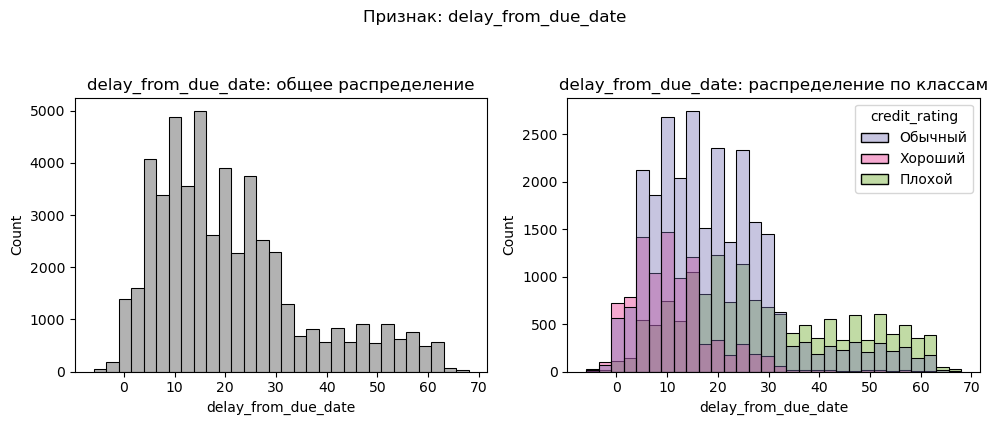

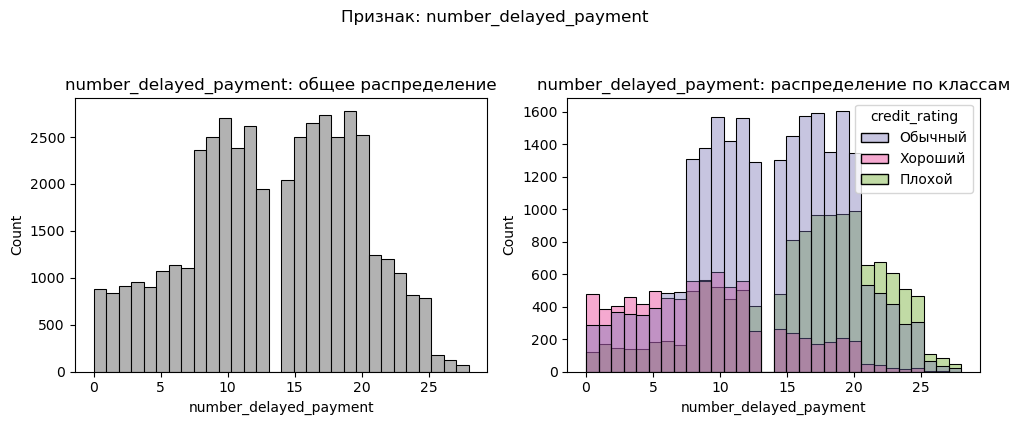

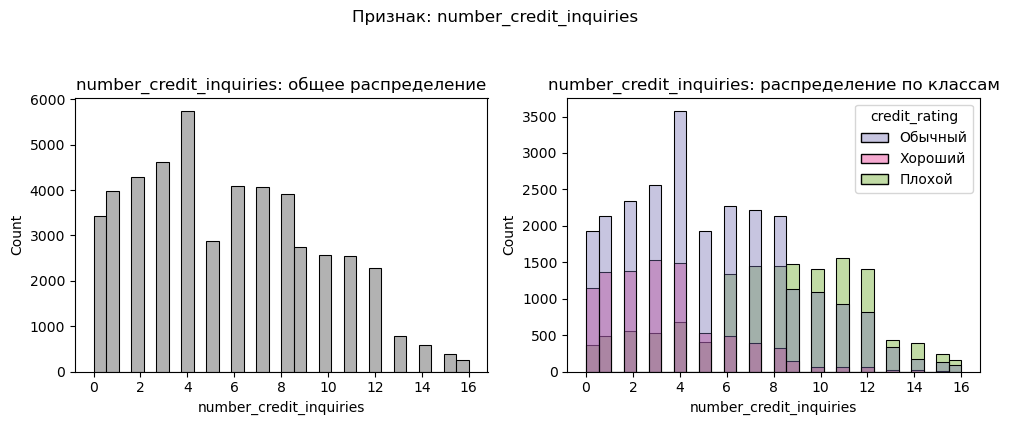

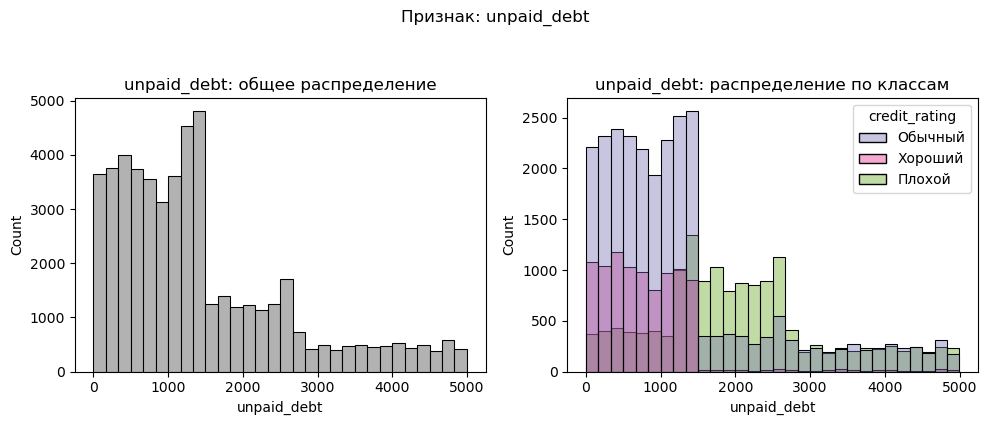

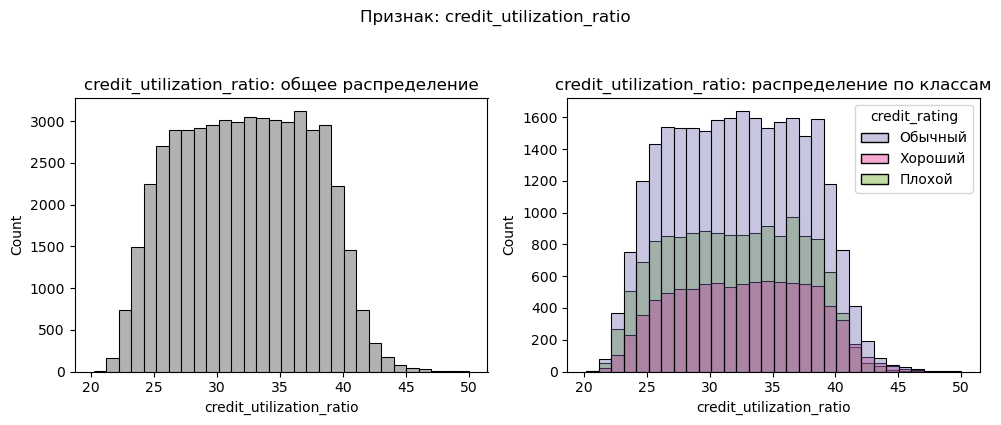

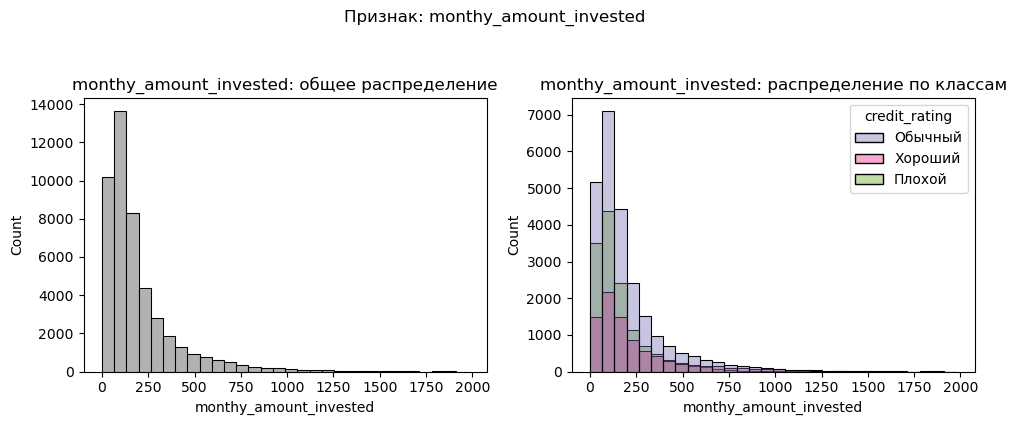

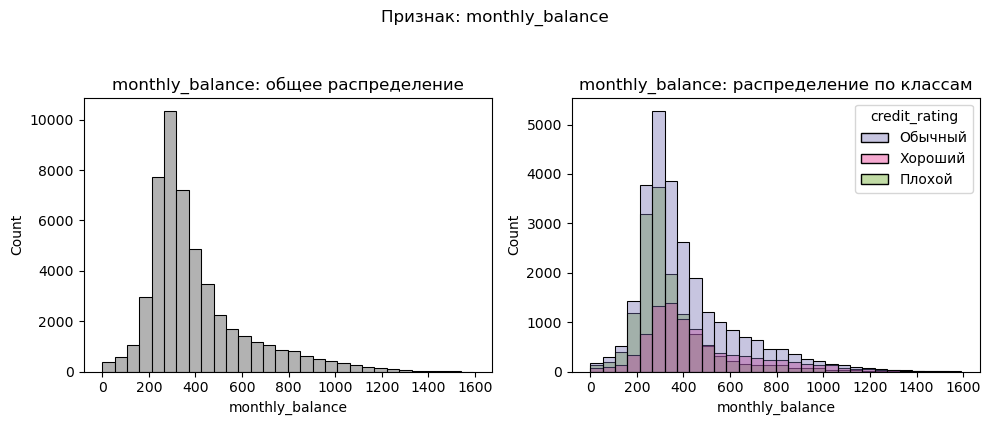

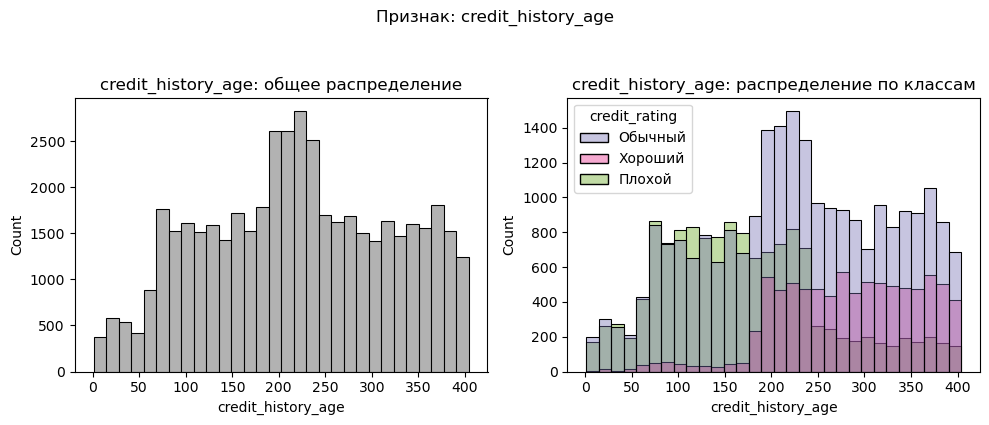

In [74]:
for feature in num_cols:
    fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
    sns.histplot(X_train[feature], bins=30, ax=ax[0], color='gray', alpha=0.6)
    ax[0].set_title(f'{feature}: общее распределение')
    ax[0].set_xlabel(feature)

    sns.histplot(
        data=X_train.assign(credit_rating=y_train),
        x=feature,
        hue='credit_rating',
        bins=30,
        ax=ax[1],
        alpha=0.4,
        common_norm=False
    )
    ax[1].set_title(f'{feature}: распределение по классам')
    ax[1].set_xlabel(feature)
    
    plt.suptitle(f'Признак: {feature}', fontsize=12, y=1.05)
    plt.tight_layout()
    plt.show()
    plt.close()


In [521]:
X_train.dtypes

age                         float64
occupation                   object
annual_income               float64
monthly_salary              float64
number_bank_accounts          int64
number_credit_cards           int64
interest_rate               float64
number_loan                 float64
delay_from_due_date           int64
number_delayed_payment      float64
number_credit_inquiries     float64
unpaid_debt                 float64
credit_utilization_ratio    float64
min_amount_payment           object
monthy_amount_invested      float64
monthly_balance             float64
spendings                    object
payments                     object
credit_history_age          float64
dtype: object

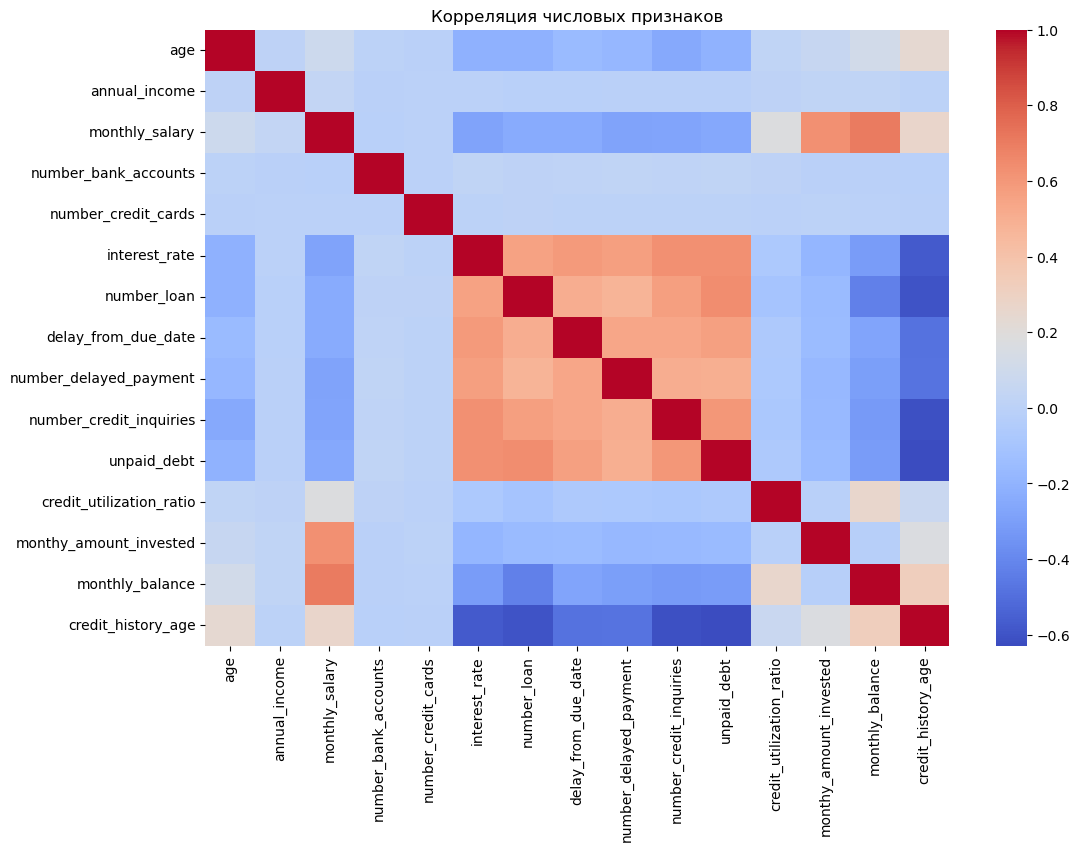

In [523]:
corr_matrix = X_train.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Корреляция числовых признаков')
plt.show()


---
### First tries

Для катбуста заполним пропуски 'nan', как он просит

In [502]:
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()

In [503]:
X_train[cat_cols] = X_train[cat_cols].fillna("nan").astype(str)
model = CatBoostClassifier(random_state=RANDOM_STATE, eval_metric='MultiClass',
                            cat_features=cat_cols, verbose=0)

model.fit(X_train, y_train)

In [504]:
X_valid[cat_cols] = X_valid[cat_cols].fillna("nan").astype(str)
y_pred = model.predict(X_valid)
print(f'Accuracy на валидации со стандартными параметрами и нативной обработкой данных CatBoost: {accuracy_score(y_pred, y_valid)}')

Accuracy на валидации со стандартными параметрами и нативной обработкой данных CatBoost: 0.72296875


In [505]:
model = XGBClassifier(random_state=RANDOM_STATE, eval_metric='merror',
                            enable_categorical=True)
X_train[cat_cols] = X_train[cat_cols].astype('category')
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_valid = encoder.transform(y_valid)
model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'merror'


In [506]:
X_valid[cat_cols] = X_valid[cat_cols].astype('category')
y_pred = model.predict(X_valid)
score = accuracy_score(y_pred, y_valid)
print(f'Accuracy на валидации со стандартными параметрами и нативной обработкой данных XGBoost: {score}')

Accuracy на валидации со стандартными параметрами и нативной обработкой данных XGBoost: 0.744609375


In [507]:
X_train[cat_cols] = X_train[cat_cols].astype('category')
model = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [510]:
X_valid[cat_cols] = X_valid[cat_cols].astype('category')
y_pred = model.predict(X_valid)
print(f'Accuracy на валидации со стандартными параметрами и нативной обработкой данных LGBM: {accuracy_score(y_pred, y_valid)}')

Accuracy на валидации со стандартными параметрами и нативной обработкой данных LGBM: 0.717109375


XGBoost быстро учится и даёт неплохие результаты. Возьмём его для оценки важности признаков

In [381]:
X_train[cat_cols] = X_train[cat_cols].astype('category')
X_valid[cat_cols] = X_valid[cat_cols].astype('category')
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_valid = encoder.transform(y_valid)
scores = {}

for column in X_train.columns:
    X_train_dropped = X_train.drop([column], axis=1)
    X_valid_dropped = X_valid.drop([column], axis=1)
    model = XGBClassifier(random_state=RANDOM_STATE, eval_metric='merror',
                            enable_categorical=True)
    model.fit(X_train_dropped, y_train)
    y_pred = model.predict(X_valid_dropped)
    scores[column] = score - accuracy_score(y_pred, y_valid)

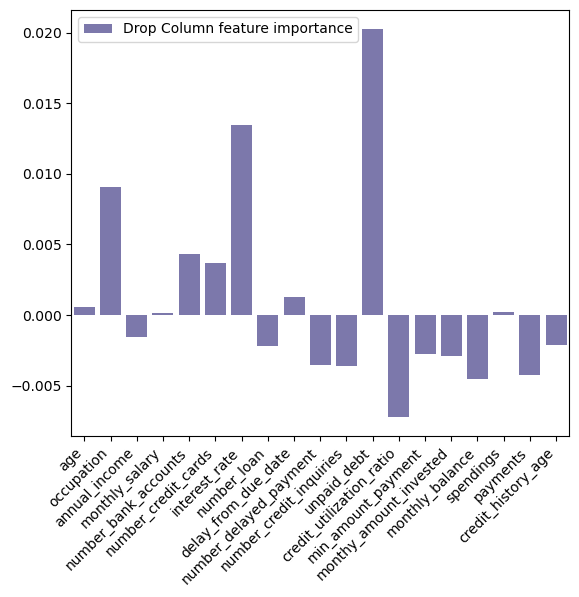

In [422]:
sns.barplot(scores, label='Drop Column feature importance')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')  
plt.legend()
plt.show()

Сравним с важностью по частоте использования признака в деревьях

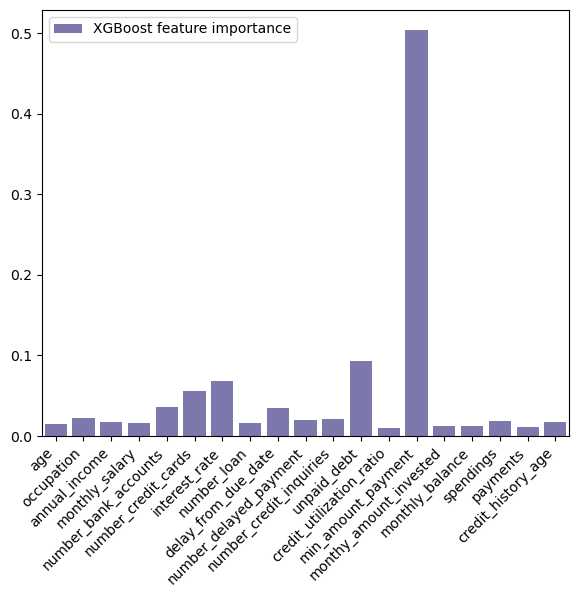

In [421]:
sns.barplot(y=model.feature_importances_, x=model.feature_names_in_, label='XGBoost feature importance')
plt.tight_layout()
plt.xticks(rotation=45, ha='right') 
plt.legend()
plt.show()

In [408]:
print(model.feature_names_in_)

min_amount_payment


Что будет, если убрать отрицательные

In [386]:
X_train_dropped = X_train.drop(['annual_income', 'number_loan', 'number_delayed_payment', 'credit_utilization_ratio', 
                                'min_amount_payment', 'monthy_amount_invested', 'monthly_balance', 'payments', 'credit_history_age'], axis=1)
X_valid_dropped = X_valid.drop(['annual_income', 'number_loan', 'number_delayed_payment', 'credit_utilization_ratio', 
                                'min_amount_payment', 'monthy_amount_invested', 'monthly_balance', 'payments', 'credit_history_age'], axis=1)
model = XGBClassifier(random_state=RANDOM_STATE, eval_metric='merror',
                        enable_categorical=True)
model.fit(X_train_dropped, y_train)
y_pred = model.predict(X_valid_dropped)
print(f'Метрика с выброшенными переоцененными признаками:{ accuracy_score(y_pred, y_valid)}')

Метрика с выброшенными переоцененными признаками:0.749453125


Попробуем подобрать гиперпараметры

In [434]:
%%time

model = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, eval_metric='merror',
                            enable_categorical=True),
    param_distributions={
        'max_depth': np.arange(3, 8),
        'n_estimators': np.arange(10, 200),
        'learning_rate': np.linspace(0.05, 0.3, 300)
    },
    cv=5,
    verbose=1,
    n_iter=30,
    random_state=RANDOM_STATE
)

X_valid[cat_cols] = X_valid[cat_cols].astype('category')
X_train[cat_cols] = X_train[cat_cols].astype('category')

encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_valid = encoder.transform(y_valid)

model.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CPU times: user 34min 49s, sys: 43.2 s, total: 35min 32s
Wall time: 1h 50min 51s


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'learning_rate': array([0.05 ..., 0.3 ]), 'max_depth': array([3, 4, 5, 6, 7]), 'n_estimators': array([ 10, ...97, 198, 199])}"
,n_iter,30
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [438]:
xgb_n  = 180
xgb_depth = 7
xgb_lr = 0.187

In [437]:
print(f'Accuracy на валидации с подобранными параметрами и нативной обработкой данных XGBoost: {accuracy_score(model.predict(X_valid), y_valid)}')

Accuracy на валидации с подобранными параметрами и нативной обработкой данных XGBoost: 0.759453125


Отправим результат в качестве первого на Kaggle

In [442]:
estimator = XGBClassifier(random_state=RANDOM_STATE, eval_metric='merror', max_depth=xgb_depth, n_estimators=xgb_n,
                        enable_categorical=True, learning_rate=xgb_lr)
X[cat_cols] = X[cat_cols].astype('category')
encoder = LabelEncoder()
y = encoder.fit_transform(y)
estimator.fit(X, y)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'merror'


Можно нарисовать важность признаков

In [473]:
X_test[cat_cols] = X_test[cat_cols].astype('category')
y_pred = encoder.inverse_transform(estimator.predict(X_test))
submission = pd.DataFrame({
    'index': pd.read_csv('sample_submission.csv')['index'],
    'credit_rating': y_pred       
})

submission.to_csv('submission.csv', index=False, encoding='utf-8')

---
### Second tries

In [ ]:
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].fillna("nan").astype(str)
X_test[cat_cols] = X_test[cat_cols].fillna("nan").astype(str)

In [34]:
%%time

param_distributions = {
    'n_estimators': np.arange(50, 300),
    'max_depth': np.arange(3, 8),
    'learning_rate': np.linspace(0.01, 0.3, 50),
    'min_data_in_leaf': np.arange(1, 7),
    'l2_leaf_reg': np.linspace(0, 10, 20),
    'rsm': np.linspace(0.5, 1, 10).astype(float)
}

base_model = CatBoostClassifier(
    cat_features=cat_cols,
    random_state=RANDOM_STATE,
    verbose=False
)

CatBoost_CV = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    scoring='accuracy',
    n_iter=30,
    n_jobs=-1,
    cv=5,
    random_state=RANDOM_STATE,
    verbose=1
)

CatBoost_CV.fit(X, y)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CPU times: user 1min 6s, sys: 9.66 s, total: 1min 16s
Wall time: 15min 49s


,estimator,<catboost.cor...x7cce26956c20>
,param_distributions,"{'l2_leaf_reg': array([ 0. ... 10. ]), 'learning_rate': array([0.01 ..., 0.3 ]), 'max_depth': array([3, 4, 5, 6, 7]), 'min_data_in_leaf': array([1, 2, 3, 4, 5, 6]), ...}"
,n_iter,30
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [36]:
y_pred = CatBoost_CV.predict(X_test).reshape(-1)
submission = pd.DataFrame({
    'index': pd.read_csv('sample_submission.csv')['index'],
    'credit_rating': y_pred       
})

submission.to_csv('CatBoost_CV.csv', index=False, encoding='utf-8')

Посмотрим на важность признаков, будем далее генерить фичи

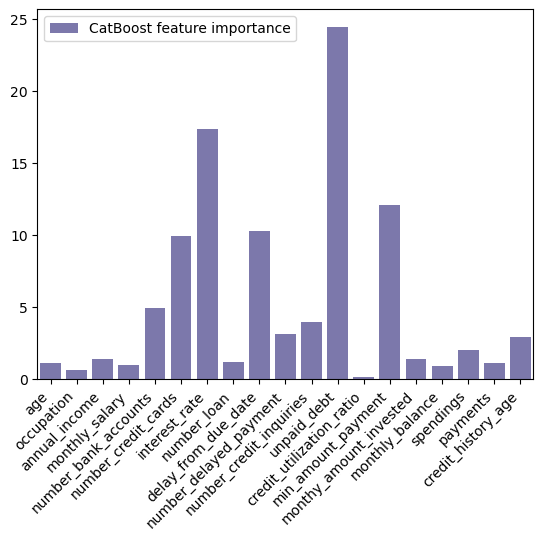

In [38]:
sns.barplot(y=CatBoost_CV.best_estimator_.get_feature_importance(), x=CatBoost_CV.best_estimator_.feature_names_, label='CatBoost feature importance')
plt.xticks(rotation=45, ha='right')
plt.show()

Попробуем также LGBM

In [39]:
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")
X_test[cat_cols] = X_test[cat_cols].astype("category")

In [40]:
%%time

LGBM_CV = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_distributions={
        'max_depth': np.arange(3, 6),
        'n_estimators': np.arange(10, 100),
        'learning_rate': np.linspace(0.05, 0.3, 300)
    },
    cv=5,
    verbose=1,
    n_jobs=-1,
    n_iter=30,
    random_state=RANDOM_STATE
)

LGBM_CV.fit(X, y)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CPU times: user 2.22 s, sys: 123 ms, total: 2.34 s
Wall time: 1min 2s


,estimator,"LGBMClassifie...2, verbose=-1)"
,param_distributions,"{'learning_rate': array([0.05 ..., 0.3 ]), 'max_depth': array([3, 4, 5]), 'n_estimators': array([10, 11..., 97, 98, 99])}"
,n_iter,30
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [41]:
y_pred = LGBM_CV.predict(X_test).reshape(-1)
submission = pd.DataFrame({
    'index': pd.read_csv('sample_submission.csv')['index'],
    'credit_rating': y_pred       
})

submission.to_csv('LGBM_CV.csv', index=False, encoding='utf-8')

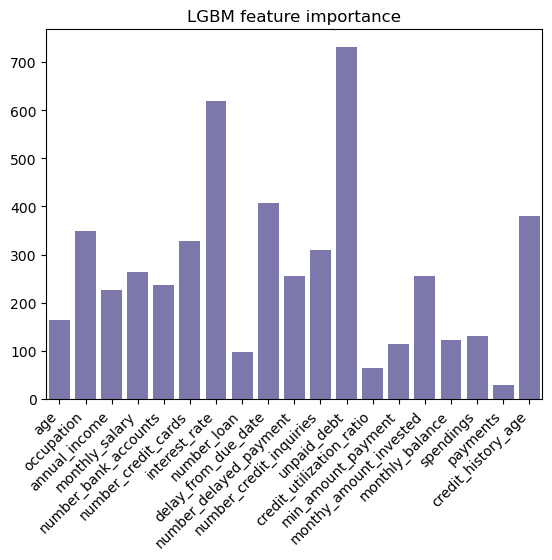

In [42]:
sns.barplot(y=model.best_estimator_.feature_importances_, x=model.best_estimator_.feature_names_in_)
plt.xticks(rotation=45, ha='right')
plt.title('LGBM feature importance')
plt.show()

В унисон две модели считают важными interest_rate и unpaid_dept. Рассмотрим их гистограммы Подробнее


---

### Feature Generation 1

Проквантуем по внешнему виду

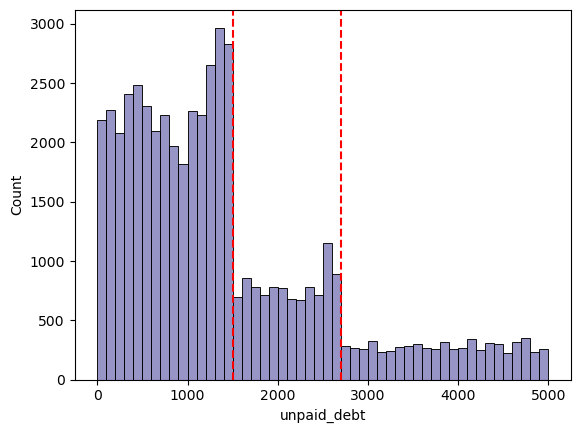

In [56]:
sns.histplot(X_train['unpaid_debt'], bins=50)
plt.axvline(1500, color='r', linestyle='--')
plt.axvline(2700, color='r', linestyle='--')
plt.show()

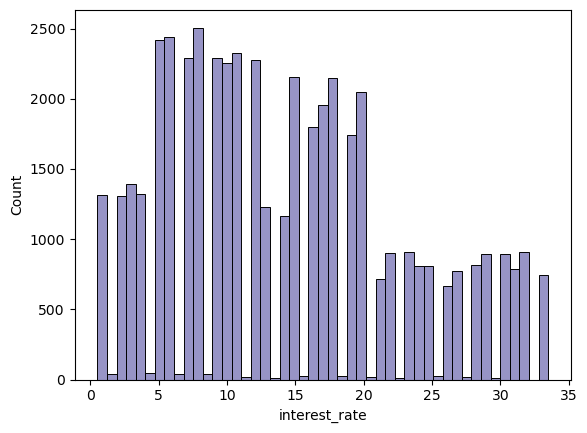

In [46]:
sns.histplot(X_train['interest_rate'])
plt.show()

Аналогично

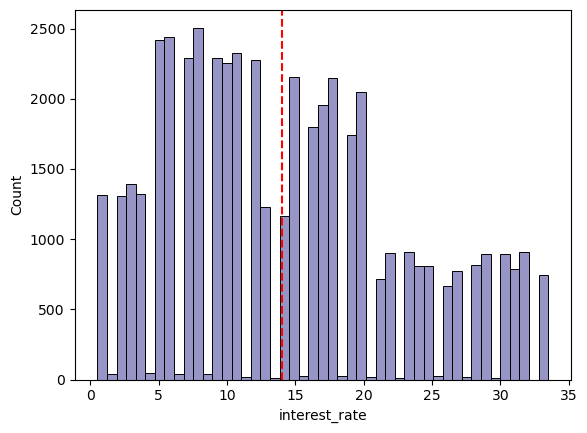

In [75]:
sns.histplot(X_train['interest_rate'])
plt.axvline(14, color='r', linestyle='--')
plt.show()

In [21]:
def unpaid_debt_bins(X):
    unpaid_debt_bins = []
    for i in X.index:
        stroke = X.loc[i, 'unpaid_debt']
        if stroke < 1500:
            unpaid_debt_bins.append(1)
        elif stroke < 2700:
            unpaid_debt_bins.append(2)
        else:
            unpaid_debt_bins.append(3)
    X['unpaid_debt_bins'] = unpaid_debt_bins
    return X

In [76]:
def interest_rate_bins(X):
    interest_rate_bins = []
    for i in X.index:
        stroke = X.loc[i, 'interest_rate']
        if stroke < 14:
            interest_rate_bins.append(0)
        else:
            interest_rate_bins.append(1)
    X['interest_rate_bins'] = interest_rate_bins
    return X

Рассмотрим другой важный признак

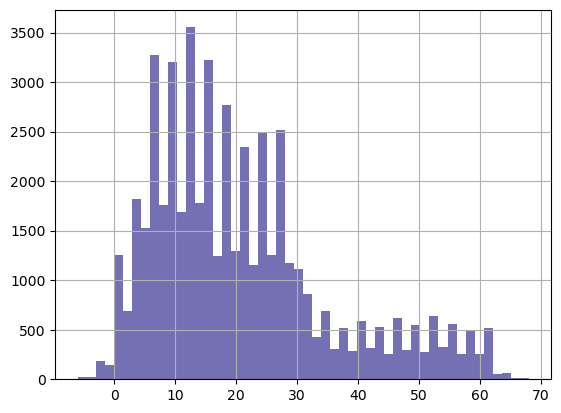

In [111]:
X_train['delay_from_due_date'].hist(bins=50)
plt.show()

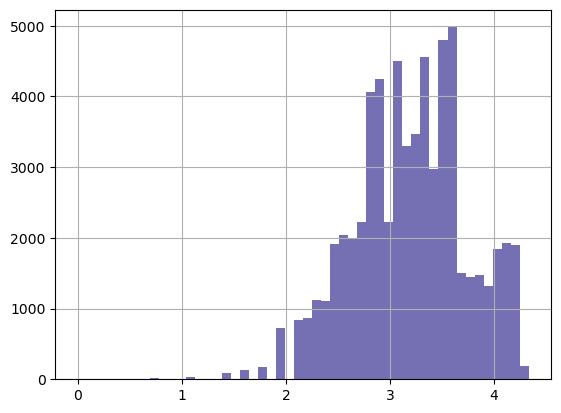

In [162]:
np.log1p(X_train['delay_from_due_date'] - X_train['delay_from_due_date'].min()).hist(bins=50)
plt.show()

In [163]:
X_train['ln_delay_from_due_date'] = np.log1p(X_train['delay_from_due_date'] - X_train['delay_from_due_date'].min())

In [168]:
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")
X_test[cat_cols] = X_test[cat_cols].astype("category")

In [171]:
X, X_test = unpaid_debt_bins(X), unpaid_debt_bins(X_test)
X, X_test = interest_rate_bins(X), interest_rate_bins(X_test)
X['ln_delay_from_due_date'] = np.log1p(X['delay_from_due_date'] - X['delay_from_due_date'].min())
X_test['ln_delay_from_due_date'] = np.log1p(X_test['delay_from_due_date'] - X_test['delay_from_due_date'].min())

In [175]:
%%time

LGBM_CV = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_distributions={
        'max_depth': np.arange(3, 7),
        'n_estimators': np.arange(10, 100),
        'learning_rate': np.linspace(0.05, 0.3, 300)
    },
    cv=5,
    verbose=1,
    n_jobs=-1,
    n_iter=100,
    random_state=RANDOM_STATE
)

LGBM_CV.fit(X, y)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
CPU times: user 6.38 s, sys: 800 ms, total: 7.18 s
Wall time: 9min 56s


,estimator,"LGBMClassifie...2, verbose=-1)"
,param_distributions,"{'learning_rate': array([0.05 ..., 0.3 ]), 'max_depth': array([3, 4, 5, 6]), 'n_estimators': array([ 10, ...97, 198, 199])}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [177]:
y_pred = LGBM_CV.predict(X_test).reshape(-1)
submission = pd.DataFrame({
    'index': pd.read_csv('sample_submission.csv')['index'],
    'credit_rating': y_pred       
})

submission.to_csv('LGBM_CV.csv', index=False, encoding='utf-8')

In [178]:
LGBM_CV.best_params_

{'n_estimators': np.int64(87),
 'max_depth': np.int64(5),
 'learning_rate': np.float64(0.07090301003344482)}

Качество стало хуже

---

### Feature Generation 2

In [ ]:
%%time

LGBM_CV = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_distributions={
        'max_depth': np.arange(3, 8),
        'n_estimators': np.arange(10, 100),
        'learning_rate': np.linspace(0.05, 0.3, 300)
    },
    cv=5,
    verbose=1,
    n_jobs=-1,
    n_iter=50,
    random_state=RANDOM_STATE
)

LGBM_CV.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [321]:
LGBM_CV.best_score_

np.float64(0.669046875)

In [245]:
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

In [18]:
def scoring(X, y):
    score = cross_val_score(estimator=LGBMClassifier(),
                            X=X,
                            y=y,
                            cv=5,
                            scoring=make_scorer(accuracy_score),
                            n_jobs=-1
                            )
    return score.mean()
print(f'Метрика до добавления фич: {scoring(X, y)}')

Метрика до добавления фич: 0.668671875


In [246]:
X['payment'] = X['unpaid_debt'] * 0.01 * X['interest_rate']
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.664640625


In [281]:
X['sqrt_monthly_salary'] = np.log1p(X['monthly_salary'])
X = X.drop(['monthly_salary'], axis=1)
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.667390625


In [280]:
X['diff'] = X['monthly_salary'] - X['monthy_amount_invested']
X['ln_monthly_salary'] = np.log1p(X['monthly_salary'])
X = X.drop(['monthly_salary'], axis=1)
X['ln_monthy_amount_invested'] = np.log1p(X['monthy_amount_invested'])
X = X.drop(['monthy_amount_invested'], axis=1)
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.66696875


In [259]:
X['ln_age'] = np.log1p(X['age'])
X = X.drop(['age'], axis=1)
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2559
[LightGBM] [Info] Number of data points in the train set: 51200, number of used features: 19
[LightGBM] [Info] Start training from score -0.646741
[LightGBM] [Info] Start training from score -1.226557
[LightGBM] [Info] Start training from score -1.698547
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008796 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2559
[LightGBM] [Info] Number of data points in the train set: 51200, number of used features: 19
[LightGBM] [Info] Start training from score -0.646741
[LightGBM] [Info] Start training from score -1.226557
[LightGBM] [Info] Start 

In [275]:
X['ln_annual_income'] = np.log1p(X['annual_income'])
X = X.drop(['annual_income'], axis=1)
X['ln_number_bank_accounts'] = np.log1p(X['number_bank_accounts'] - X['number_bank_accounts'].min())
X = X.drop(['number_bank_accounts'], axis=1)
X['ln_number_credit_cards'] = np.log1p(X['number_credit_cards'])
X = X.drop(['number_credit_cards'], axis=1)
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.667390625


In [282]:
X['debt_per_loan'] = X['unpaid_debt'] / X['number_loan']
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.666109375


In [285]:
X['age_diff'] = X['credit_history_age'] - X['age']
X.drop('age', axis=1)
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.666453125


In [286]:
X = X.drop('monthly_salary', axis=1)
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.6663125


In [295]:
X['uniratioXdebt'] = X['credit_utilization_ratio'] * X['unpaid_debt']
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.6653593750000001


In [339]:
X['uniratioXincome'] = X['credit_utilization_ratio'] * X['annual_income']
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.667171875


In [337]:
X['rateXibalance'] = X['interest_rate'] * X['monthly_balance']
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.668328125


In [345]:
X['uniratio/debt'] = X['credit_utilization_ratio'] / X['unpaid_debt']
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.666609375


In [330]:
X['rateXbalance'] = 0.01 * X['interest_rate'] * X['monthly_balance']
X_test['rateXbalance'] = 0.01 * X_test['interest_rate'] * X_test['monthly_balance']
X_test[cat_cols] = X_test[cat_cols].astype("category")

In [327]:
%%time

LGBM_CV = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_distributions={
        'max_depth': np.arange(3, 8),
        'n_estimators': np.arange(10, 100),
        'learning_rate': np.linspace(0.05, 0.3, 300)
    },
    cv=5,
    verbose=1,
    n_jobs=-1,
    n_iter=50,
    random_state=RANDOM_STATE
)

LGBM_CV.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
CPU times: user 3.22 s, sys: 321 ms, total: 3.54 s
Wall time: 3min 5s


,estimator,"LGBMClassifie...2, verbose=-1)"
,param_distributions,"{'learning_rate': array([0.05 ..., 0.3 ]), 'max_depth': array([3, 4, 5, 6, 7]), 'n_estimators': array([10, 11..., 97, 98, 99])}"
,n_iter,50
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [328]:
LGBM_CV.best_score_

np.float64(0.6693749999999999)

In [315]:
y_pred = LGBM_CV.predict(X_test).reshape(-1)
submission = pd.DataFrame({
    'index': pd.read_csv('sample_submission.csv')['index'],
    'credit_rating': y_pred       
})

submission.to_csv('LGBM_CV.csv', index=False, encoding='utf-8')

Поднялось качество на 0.01

Попрошу гпт придумать фич, отправлю ему важности и сами признаки

In [347]:
X["debt_to_income"] = X["unpaid_debt"] / (X["annual_income"])
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.6668281250000001


In [348]:
X["invest_share"] = X["monthy_amount_invested"] / (X["monthly_salary"])
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.668546875


In [349]:
X["balance_ratio"] = X["monthly_balance"] / (X["monthly_salary"])
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.665515625


In [350]:
X["delay_rate"] = X["number_delayed_payment"] / (X["number_loan"])
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.6664843749999999


In [351]:
X["credit_pressure"] = X["credit_utilization_ratio"] * X["number_credit_cards"]
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.6682812499999999


In [364]:
X["debt_per_loan"] = X["unpaid_debt"] / (X["number_loan"])
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.6671875


In [358]:
X["occupation_behaviour"] = X["occupation"].astype(str) + "_" + X["spendings"].astype(str)
X["occupation_behaviour"] = X["occupation_behaviour"].astype('category')
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.6659843750000001


In [359]:
X["invest_share"] = X["monthy_amount_invested"] / (X["monthly_salary"])
X["credit_pressure"] = X["credit_utilization_ratio"] * X["number_credit_cards"]


X_test['rateXibalance'] = 0.01 * X_test['interest_rate'] * X_test['monthly_balance']
X_test["credit_pressure"] = X_test["credit_utilization_ratio"] * X_test["number_credit_cards"]
X_test["invest_share"] = X_test["monthy_amount_invested"] / (X_test["monthly_salary"])

X[cat_cols] = X[cat_cols].astype("category")
X_test[cat_cols] = X_test[cat_cols].astype("category")

In [360]:
%%time

LGBM_CV = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_distributions={
        'max_depth': np.arange(3, 8),
        'n_estimators': np.arange(10, 200),
        'learning_rate': np.linspace(0.05, 0.3, 300)
    },
    cv=5,
    verbose=1,
    n_jobs=-1,
    n_iter=30,
    random_state=RANDOM_STATE
)

LGBM_CV.fit(X, y)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
CPU times: user 14.7 s, sys: 2.05 s, total: 16.8 s
Wall time: 23min 50s


,estimator,"LGBMClassifie...2, verbose=-1)"
,param_distributions,"{'learning_rate': array([0.05 ..., 0.3 ]), 'max_depth': array([3, 4, 5, 6, 7]), 'n_estimators': array([ 10, ...97, 198, 199])}"
,n_iter,200
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [361]:
LGBM_CV.best_score_

np.float64(0.6698906250000001)

In [363]:
y_pred = LGBM_CV.predict(X_test).reshape(-1)
submission = pd.DataFrame({
    'index': pd.read_csv('sample_submission.csv')['index'],
    'credit_rating': y_pred       
})

submission.to_csv('LGBM_CV.csv', index=False, encoding='utf-8')

На тесте метрика сильно ниже

In [20]:
X["invest_share"] = X["monthy_amount_invested"] / (X["monthly_salary"])
X["credit_pressure"] = X["credit_utilization_ratio"] * X["number_credit_cards"]
X['rateXibalance'] = 0.01 * X['interest_rate'] * X['monthly_balance']
X = X.drop('credit_utilization_ratio', axis=1)

print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.668671875


In [377]:
X["invest_share"] = X["monthy_amount_invested"] / (X["monthly_salary"])
X["credit_pressure"] = X["credit_utilization_ratio"] * X["number_credit_cards"]
X['rateXibalance'] = 0.01 * X['interest_rate'] * X['monthly_balance']
X = X.drop('credit_utilization_ratio', axis=1)

X_test['rateXibalance'] = 0.01 * X_test['interest_rate'] * X_test['monthly_balance']
X_test["credit_pressure"] = X_test["credit_utilization_ratio"] * X_test["number_credit_cards"]
X_test["invest_share"] = X_test["monthy_amount_invested"] / (X_test["monthly_salary"])
X_test = X_test.drop('credit_utilization_ratio', axis=1)

X[cat_cols] = X[cat_cols].astype("category")
X_test[cat_cols] = X_test[cat_cols].astype("category")

In [378]:
%%time

LGBM_CV = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_distributions={
        'max_depth': np.arange(3, 8),
        'n_estimators': np.arange(10, 200),
        'learning_rate': np.linspace(0.05, 0.3, 300)
    },
    cv=5,
    verbose=1,
    n_jobs=-1,
    n_iter=50,
    random_state=RANDOM_STATE
)

LGBM_CV.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
CPU times: user 4.49 s, sys: 550 ms, total: 5.04 s
Wall time: 6min 9s


,estimator,"LGBMClassifie...2, verbose=-1)"
,param_distributions,"{'learning_rate': array([0.05 ..., 0.3 ]), 'max_depth': array([3, 4, 5, 6, 7]), 'n_estimators': array([ 10, ...97, 198, 199])}"
,n_iter,50
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [379]:
LGBM_CV.best_score_

np.float64(0.668765625)

In [380]:
y_pred = LGBM_CV.predict(X_test).reshape(-1)
submission = pd.DataFrame({
    'index': pd.read_csv('sample_submission.csv')['index'],
    'credit_rating': y_pred       
})

submission.to_csv('LGBM_CV.csv', index=False, encoding='utf-8')

In [ ]:
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].fillna("nan").astype(str)
X_test[cat_cols] = X_test[cat_cols].fillna("nan").astype(str)

%%time

param_distributions = {
    'n_estimators': np.arange(50, 300),
    'max_depth': np.arange(3, 8),
    'learning_rate': np.linspace(0.01, 0.3, 50),
    'min_data_in_leaf': np.arange(1, 7),
    'l2_leaf_reg': np.linspace(0, 10, 20),
    'rsm': np.linspace(0.5, 1, 10).astype(float)
}

base_model = CatBoostClassifier(
    cat_features=cat_cols,
    random_state=RANDOM_STATE,
    verbose=False
)

CatBoost_CV = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    scoring='accuracy',
    n_iter=30,
    n_jobs=-1,
    cv=5,
    random_state=RANDOM_STATE,
    verbose=1
)

CatBoost_CV.fit(X, y)

y_pred = CatBoost_CV.predict(X_test).reshape(-1)
submission = pd.DataFrame({
    'index': pd.read_csv('sample_submission.csv')['index'],
    'credit_rating': y_pred       
})

submission.to_csv('CatBoost_CV.csv', index=False, encoding='utf-8')

In [80]:
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X = unpaid_debt_bins(X)
X['unpaid_debt_bins'] = X['unpaid_debt_bins'].astype('category')
X_test = unpaid_debt_bins(X_test)
X_test['unpaid_debt_bins'] = X_test['unpaid_debt_bins'].astype('category')
X[cat_cols] = X[cat_cols].astype("category")
X_test[cat_cols] = X_test[cat_cols].astype("category")

In [81]:
%%time

LGBM_CV = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_distributions={
        'max_depth': np.arange(3, 8),
        'n_estimators': np.arange(10, 200),
        'learning_rate': np.linspace(0.05, 0.3, 300)
    },
    cv=5,
    verbose=1,
    n_jobs=-1,
    n_iter=200,
    random_state=RANDOM_STATE
)

LGBM_CV.fit(X, y)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
CPU times: user 8.08 s, sys: 1.35 s, total: 9.43 s
Wall time: 19min 56s


,estimator,"LGBMClassifie...2, verbose=-1)"
,param_distributions,"{'learning_rate': array([0.05 ..., 0.3 ]), 'max_depth': array([3, 4, 5, 6, 7]), 'n_estimators': array([ 10, ...97, 198, 199])}"
,n_iter,200
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [82]:
LGBM_CV.best_score_

np.float64(0.670921875)

In [83]:
y_pred = LGBM_CV.predict(X_test).reshape(-1)
submission = pd.DataFrame({
    'index': pd.read_csv('sample_submission.csv')['index'],
    'credit_rating': y_pred       
})

submission.to_csv('LGBM_CV.csv', index=False, encoding='utf-8')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013330 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2624
[LightGBM] [Info] Number of data points in the train set: 51200, number of used features: 20
[LightGBM] [Info] Start training from score -0.646741
[LightGBM] [Info] Start training from score -1.226557
[LightGBM] [Info] Start training from score -1.698547
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2563
[LightGBM] [Info] Number of data points in the train set: 51200, number of used features: 21
[LightGBM] [Info] Start training from score -0.646741
[LightGBM] [Info] Start training from score -1.226623
[LightGBM] [Info] Start training from score -1.698440
[LightGBM] [Info] Auto-choosing ro

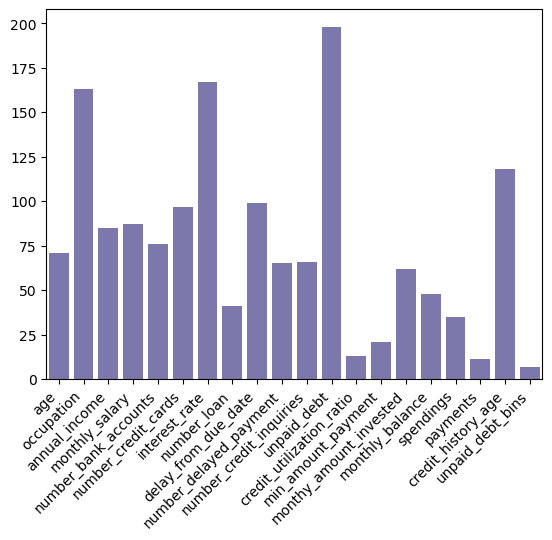

In [90]:
sns.barplot(y=LGBM_CV.best_estimator_.feature_importances_, x=LGBM_CV.best_estimator_.feature_names_in_)
plt.xticks(rotation=45, ha='right')
plt.show()

In [91]:
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

In [92]:
LGBM_CV.fit(X, y)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,"LGBMClassifie...2, verbose=-1)"
,param_distributions,"{'learning_rate': array([0.05 ..., 0.3 ]), 'max_depth': array([3, 4, 5, 6, 7]), 'n_estimators': array([ 10, ...97, 198, 199])}"
,n_iter,1
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [79]:
X = unpaid_debt_bins(X)
# X = interest_rate_bins(X)
# X['interest_rate_bins'] = X['interest_rate'].astype('category')
X['unpaid_debt_bins'] = X['unpaid_debt_bins'].astype('category')
# X['rateXibalance'] = 0.01 * X['interest_rate'] * X['monthly_balance']
# X.drop('interest_rate', axis=1)
print(scoring(X, y))
X_train, X_valid, y_train, y_valid, X_test, X, y = preproc()
X[cat_cols] = X[cat_cols].astype("category")

0.668984375


---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока